## Analysis Setup

This analysis uses SQL and Python to investigate the marketplace from a business perspective. We will move from understanding the data to answering questions around **customer retention, delivery performance, seller concentration, and payment behavior**.


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

## Understand the Available Data

Before answering business questions, we first inspect the available data and its structure. This establishes which datasets contain customer, order, delivery, seller, and payment information and how they can be connected.


In [2]:
duckdb.sql(r"SELECT * FROM 'C:\Users\Sahil\OneDrive\Desktop\jupyter lab\Project 1\Data\archive\olist_orders_dataset.csv' LIMIT 5").df() 

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


## Build the Analysis Data Layer

We identify the source files available in the dataset so the relevant tables can be loaded into a single SQL environment. This creates a consistent foundation for joining operational and customer-level information.


In [3]:
import os
os.listdir(r'C:\Users\Sahil\OneDrive\Desktop\jupyter lab\Project 1\Data\archive') 

['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

## Load the Data for Analysis

The relevant CSV files are loaded into DuckDB so we can analyze multiple related datasets with SQL. This is important because the business questions require combining information across orders, customers, sellers, reviews, and payments.


In [4]:
import duckdb

con = duckdb.connect('olist.duckdb')

data_path = r'C:\Users\Sahil\OneDrive\Desktop\jupyter lab\Project 1\Data\archive'

tables = {
    'customers': 'olist_customers_dataset.csv',
    'geolocation': 'olist_geolocation_dataset.csv',
    'orders': 'olist_orders_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'order_payments': 'olist_order_payments_dataset.csv',
    'order_reviews': 'olist_order_reviews_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'category_translation': 'product_category_name_translation.csv'
}

for table_name, filename in tables.items():
    filepath = os.path.join(data_path, filename)
    con.execute(f"""
        CREATE OR REPLACE TABLE {table_name} AS
        SELECT * FROM read_csv_auto('{filepath}')
    """)
    print(f"Loaded {table_name}")

Loaded customers
Loaded geolocation
Loaded orders
Loaded order_items
Loaded order_payments
Loaded order_reviews
Loaded products
Loaded sellers
Loaded category_translation


## Validate Data Coverage

Before calculating any business metrics, we check the row counts of the loaded tables. This is a basic data-quality step that confirms the available data and helps us understand the scale of each dataset.


In [5]:
# Checking row counts for every table
for table_name in tables.keys():
    count = con.execute(f"SELECT COUNT(*) FROM {table_name}").fetchone()[0]
    print(f"{table_name}: {count} rows")

customers: 99441 rows
geolocation: 1000163 rows
orders: 99441 rows
order_items: 112650 rows
order_payments: 103886 rows
order_reviews: 99224 rows
products: 32951 rows
sellers: 3095 rows
category_translation: 71 rows


## Understand Table Structure

We inspect the schema of the core tables to identify the fields needed for joins, filtering, and metric calculations. Understanding the grain and available dates is especially important before building customer and delivery metrics.


In [26]:
con.execute("DESCRIBE orders").df()

,column_name,column_type,null,key,default,extra
0,order_id,VARCHAR,YES,None,None,None
1,customer_id,VARCHAR,YES,None,None,None
2,order_status,VARCHAR,YES,None,None,None
3,order_purchase_timestamp,TIMESTAMP,YES,None,None,None
4,order_approved_at,TIMESTAMP,YES,None,None,None
5,order_delivered_carrier_date,TIMESTAMP,YES,None,None,None
6,order_delivered_customer_date,TIMESTAMP,YES,None,None,None
7,order_estimated_delivery_date,TIMESTAMP,YES,None,None,None


In [7]:
con.execute("DESCRIBE order_items").df()

,column_name,column_type,null,key,default,extra
0,order_id,VARCHAR,YES,None,None,None
1,order_item_id,BIGINT,YES,None,None,None
2,product_id,VARCHAR,YES,None,None,None
3,seller_id,VARCHAR,YES,None,None,None
4,shipping_limit_date,TIMESTAMP,YES,None,None,None
5,price,DOUBLE,YES,None,None,None
6,freight_value,DOUBLE,YES,None,None,None


## Establish the Order-Level View

We first inspect individual orders to understand how order status, purchase dates, estimated delivery dates, and actual delivery dates are represented. This provides the foundation for the order funnel and delivery analysis.


In [8]:
con.execute("SELECT * FROM orders LIMIT 5").df()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


## Question: What Does the Order Funnel Look Like?

We examine the distribution of order statuses to understand how many orders were successfully delivered versus cancelled, unavailable, or otherwise incomplete. This helps define which orders can be reliably used for downstream customer and delivery analysis.


In [9]:
con.execute("""
    SELECT order_status, COUNT(*) AS count
    FROM orders
    GROUP BY order_status
    ORDER BY count DESC
""").df()

,order_status,count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


## Question: How Is the Customer Base Represented?

We inspect the customer identifiers and geographic attributes to understand the distinction between an individual customer record and a unique customer. This distinction is important when measuring repeat purchasing without double-counting customers.


In [10]:
con.execute("SELECT customer_id, customer_unique_id, customer_state FROM customers LIMIT 5").df()

,customer_id,customer_unique_id,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,SP


## Question: How Strong Is Customer Retention?

We classify customers based on their number of delivered orders to distinguish **one-time customers from repeat customers**. This gives us a first view of customer retention and whether repeat purchasing is a meaningful part of the marketplace.


In [11]:
con.execute("""
    WITH customer_order_counts AS (
        SELECT c.customer_unique_id, COUNT(DISTINCT o.order_id) AS num_orders
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_unique_id
    )
    SELECT 
        CASE WHEN num_orders > 1 THEN 'repeat' ELSE 'one-time' END AS customer_type,
        COUNT(*) AS num_customers,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_of_customers
    FROM customer_order_counts
    GROUP BY customer_type
""").df()

,customer_type,num_customers,pct_of_customers
0,repeat,2801,3.0
1,one-time,90557,97.0


## Question: Where Is Customer Retention Strongest?

We break repeat purchasing down by customer state to identify geographic differences in retention. The goal is to identify markets with stronger customer loyalty and markets where retention may have more room for improvement.


In [12]:
con.execute("""
    WITH customer_order_counts AS (
        SELECT c.customer_unique_id, c.customer_state, COUNT(DISTINCT o.order_id) AS num_orders
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_unique_id, c.customer_state
    )
    SELECT 
        customer_state,
        COUNT(*) AS total_customers,
        SUM(CASE WHEN num_orders > 1 THEN 1 ELSE 0 END) AS repeat_customers,
        ROUND(100.0 * SUM(CASE WHEN num_orders > 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS repeat_rate_pct
    FROM customer_order_counts
    GROUP BY customer_state
    HAVING COUNT(*) >= 100
    ORDER BY repeat_rate_pct DESC
""").df()

,customer_state,total_customers,repeat_customers,repeat_rate_pct
0,RO,231,9.0,3.90
1,MT,856,28.0,3.27
2,RJ,11917,387.0,3.25
3,SP,39156,1213.0,3.10
4,GO,1895,58.0,3.06
5,RS,5168,157.0,3.04
6,ES,1928,56.0,2.90
7,PR,4769,138.0,2.89
8,MG,11001,318.0,2.89
9,DF,2019,58.0,2.87


## Question: Does Delivery Performance Affect Customer Experience?

We compare the actual delivery date with the estimated delivery date and connect the resulting delivery delay to customer review scores. This allows us to move from measuring operational performance to understanding its effect on customer satisfaction.


In [13]:
con.execute("""
    SELECT 
        o.order_id,
        o.order_delivered_customer_date,
        o.order_estimated_delivery_date,
        DATE_DIFF('day', o.order_estimated_delivery_date, o.order_delivered_customer_date) AS days_late,
        r.review_score
    FROM orders o
    JOIN order_reviews r ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    LIMIT 10
""").df()

,order_id,order_delivered_customer_date,order_estimated_delivery_date,days_late,review_score
0,73fc7af87114b39712e6da79b0a377eb,2018-01-17 18:42:41,2018-02-02,-16,4
1,a548910a1c6147796b98fdf73dbeba33,2018-03-09 23:17:20,2018-03-14,-5,5
2,f9e4b658b201a9f2ecdecbb34bed034b,2018-02-16 17:28:48,2018-03-09,-21,5
3,658677c97b385a9be170737859d3511b,2017-04-20 09:08:35,2017-05-10,-20,5
4,8e6bfb81e283fa7e4f11123a3fb894f1,2018-02-28 16:33:35,2018-03-09,-9,5
5,b18dcdf73be66366873cd26c5724d1dc,2018-04-12 17:17:53,2018-05-03,-21,1
6,e48aa0d2dcec3a2e87348811bcfdf22b,2017-07-15 12:57:24,2017-08-03,-19,5
7,c31a859e34e3adac22f376954e19b39d,2018-08-13 18:08:28,2018-10-10,-58,5
8,9c214ac970e84273583ab523dfafd09b,2017-05-16 16:49:51,2017-05-30,-14,5
9,b9bf720beb4ab3728760088589c62129,2018-05-21 17:52:12,2018-06-06,-16,4


## Measure Customer Experience by Delivery Outcome

We group deliveries into meaningful timing categories such as early, on time, slightly late, and very late. Comparing average review scores across these groups helps quantify whether delivery delays are associated with a weaker customer experience.


In [14]:
con.execute("""
    WITH delivery_data AS (
        SELECT 
            o.order_id,
            DATE_DIFF('day', o.order_estimated_delivery_date, o.order_delivered_customer_date) AS days_late,
            r.review_score
        FROM orders o
        JOIN order_reviews r ON o.order_id = r.order_id
        WHERE o.order_status = 'delivered'
          AND o.order_delivered_customer_date IS NOT NULL
    )
    SELECT 
        CASE 
            WHEN days_late <= -7 THEN '1_early_week_plus'
            WHEN days_late > -7 AND days_late <= 0 THEN '2_on_time'
            WHEN days_late > 0 AND days_late <= 7 THEN '3_slightly_late'
            ELSE '4_very_late'
        END AS delivery_bucket,
        COUNT(*) AS num_orders,
        ROUND(AVG(review_score), 2) AS avg_review_score
    FROM delivery_data
    GROUP BY delivery_bucket
    ORDER BY delivery_bucket
""").df()

,delivery_bucket,num_orders,avg_review_score
0,1_early_week_plus,76175,4.31
1,2_on_time,13769,4.16
2,3_slightly_late,3612,2.71
3,4_very_late,2797,1.70


## Question: Which Markets Face the Highest Delivery Risk?

We compare late-delivery exposure across customer states. This helps identify geographic markets where delivery reliability is most problematic and where operational improvement could potentially have the greatest impact.


In [15]:
con.execute("""
    WITH delivery_data AS (
        SELECT 
            o.order_id,
            c.customer_state,
            DATE_DIFF('day', o.order_estimated_delivery_date, o.order_delivered_customer_date) AS days_late,
            r.review_score
        FROM orders o
        JOIN order_reviews r ON o.order_id = r.order_id
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
          AND o.order_delivered_customer_date IS NOT NULL
    )
    SELECT 
        customer_state,
        COUNT(*) AS total_orders,
        ROUND(100.0 * SUM(CASE WHEN days_late > 0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_late,
        ROUND(AVG(CASE WHEN days_late > 0 THEN review_score END), 2) AS avg_score_when_late,
        ROUND(AVG(CASE WHEN days_late <= 0 THEN review_score END), 2) AS avg_score_when_on_time
    FROM delivery_data
    GROUP BY customer_state
    HAVING COUNT(*) >= 200
    ORDER BY pct_late DESC
""").df()

,customer_state,total_orders,pct_late,avg_score_when_late,avg_score_when_on_time
0,AL,398,20.85,2.12,4.30
1,MA,716,17.04,2.18,4.18
2,SE,334,14.97,1.94,4.25
3,PI,472,13.77,2.26,4.27
4,CE,1276,13.71,2.04,4.24
5,BA,3246,11.95,2.36,4.14
6,RJ,12281,11.92,1.91,4.24
7,PA,939,10.65,1.92,4.15
8,ES,1978,10.36,2.51,4.26
9,PB,513,10.14,2.37,4.27


## Question: Which Sellers Drive Marketplace Performance?

We evaluate sellers using order volume, revenue, and delivery performance. The objective is to understand whether marketplace performance is broadly distributed or driven by a smaller group of high-performing sellers.


In [16]:
con.execute("""
    WITH seller_orders AS (
        SELECT 
            oi.seller_id,
            oi.order_id,
            oi.price,
            DATE_DIFF('day', o.order_estimated_delivery_date, o.order_delivered_customer_date) AS days_late
        FROM order_items oi
        JOIN orders o ON oi.order_id = o.order_id
        WHERE o.order_status = 'delivered'
          AND o.order_delivered_customer_date IS NOT NULL
    )
    SELECT 
        seller_id,
        COUNT(DISTINCT order_id) AS num_orders,
        ROUND(SUM(price), 2) AS total_revenue,
        ROUND(100.0 * SUM(CASE WHEN days_late > 0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_late
    FROM seller_orders
    GROUP BY seller_id
    HAVING COUNT(DISTINCT order_id) >= 20
    ORDER BY pct_late DESC
    LIMIT 20
""").df()

,seller_id,num_orders,total_revenue,pct_late
0,2709af9587499e95e803a6498a5a56e9,25,1180.56,50.00
1,54965bbe3e4f07ae045b90b0b8541f52,73,10351.70,32.10
2,821fb029fc6e495ca4f08a35d51e53a5,24,17851.62,32.00
3,ede0c03645598cdfc63ca8237acbe73d,43,2352.15,31.91
4,ad781527c93d00d89a11eecd9dcad7c1,38,6039.63,31.58
5,7f152321c60a266edc53af1925ef96c1,20,3919.80,30.00
6,2a1348e9addc1af5aaa619b1a3679d6b,48,2697.40,29.41
7,f76a3b1349b6df1ee875d1f3fa4340f0,24,4160.79,29.17
8,054694fa03fe82cec4b7551487331d74,20,8286.10,28.57
9,835f0f7810c76831d6c7d24c7a646d4d,42,4990.20,27.08


## Question: How Concentrated Is Marketplace Revenue?

We rank sellers by revenue and calculate their cumulative contribution to marketplace revenue. This shows whether a relatively small group of sellers accounts for a disproportionate share of revenue, which is important for understanding marketplace dependency.


In [17]:
con.execute("""
    WITH seller_revenue AS (
        SELECT 
            oi.seller_id,
            SUM(oi.price) AS seller_total
        FROM order_items oi
        JOIN orders o ON oi.order_id = o.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY oi.seller_id
    ),
    ranked AS (
        SELECT 
            seller_id,
            seller_total,
            RANK() OVER (ORDER BY seller_total DESC) AS revenue_rank,
            SUM(seller_total) OVER () AS platform_total
        FROM seller_revenue
    )
    SELECT 
        COUNT(*) AS num_sellers,
        ROUND(SUM(seller_total), 2) AS revenue_from_these_sellers,
        ROUND(100.0 * SUM(seller_total) / MAX(platform_total), 2) AS pct_of_platform_revenue
    FROM ranked
    WHERE revenue_rank <= 100
""").df()

,num_sellers,revenue_from_these_sellers,pct_of_platform_revenue
0,100,6018244.15,45.52


## Question: How Does Payment Structure Relate to Order Value?

We examine credit-card installment counts alongside average and median order value. This helps identify whether customers using different payment structures display meaningful differences in purchasing behavior.


In [18]:
con.execute("""
    SELECT 
        op.payment_installments,
        COUNT(*) AS num_orders,
        ROUND(AVG(op.payment_value), 2) AS avg_order_value,
        ROUND(MEDIAN(op.payment_value), 2) AS median_order_value
    FROM order_payments op
    WHERE op.payment_type = 'credit_card'
    GROUP BY op.payment_installments
    ORDER BY op.payment_installments
""").df()

,payment_installments,num_orders,avg_order_value,median_order_value
0,0,2,94.32,94.32
1,1,25455,95.87,67.87
2,2,12413,127.23,109.42
3,3,10461,142.54,110.42
4,4,7098,163.98,117.18
5,5,5239,183.47,125.97
6,6,3920,209.85,138.55
7,7,1626,187.67,140.07
8,8,4268,307.74,212.70
9,9,644,203.44,99.92


## Simplify Payment Behavior Into Actionable Segments

Individual installment counts are grouped into broader payment-behavior segments. This makes the results easier to interpret and reduces the risk of overemphasizing small groups while still capturing meaningful differences in order value and customer experience.


In [19]:
con.execute("""
    WITH order_installments AS (
        SELECT 
            op.order_id,
            MAX(op.payment_installments) AS installments,
            SUM(op.payment_value) AS total_paid
        FROM order_payments op
        WHERE op.payment_type = 'credit_card'
        GROUP BY op.order_id
    )
    SELECT 
        CASE 
            WHEN oi.installments <= 3 THEN '1_low_1to3'
            WHEN oi.installments <= 6 THEN '2_mid_4to6'
            WHEN oi.installments <= 10 THEN '3_high_7to10'
            ELSE '4_very_high_11plus'
        END AS installment_bucket,
        COUNT(*) AS num_orders,
        ROUND(AVG(oi.total_paid), 2) AS avg_order_value,
        ROUND(AVG(r.review_score), 2) AS avg_review_score,
        ROUND(100.0 * SUM(CASE WHEN o.order_status = 'canceled' THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_canceled
    FROM order_installments oi
    JOIN orders o ON oi.order_id = o.order_id
    LEFT JOIN order_reviews r ON oi.order_id = r.order_id
    GROUP BY installment_bucket
    ORDER BY installment_bucket
""").df()

,installment_bucket,num_orders,avg_order_value,avg_review_score,pct_canceled
0,1_low_1to3,48321,114.34,4.12,0.56
1,2_mid_4to6,16314,181.29,4.06,0.59
2,3_high_7to10,11927,334.39,4.00,0.65
3,4_very_high_11plus,346,356.00,3.89,0.58


## Visualize the Customer Impact of Delivery Performance

The following visualization summarizes average review scores by delivery timing. The purpose is to make the operational-to-customer relationship immediately visible and highlight whether satisfaction deteriorates as deliveries become later.


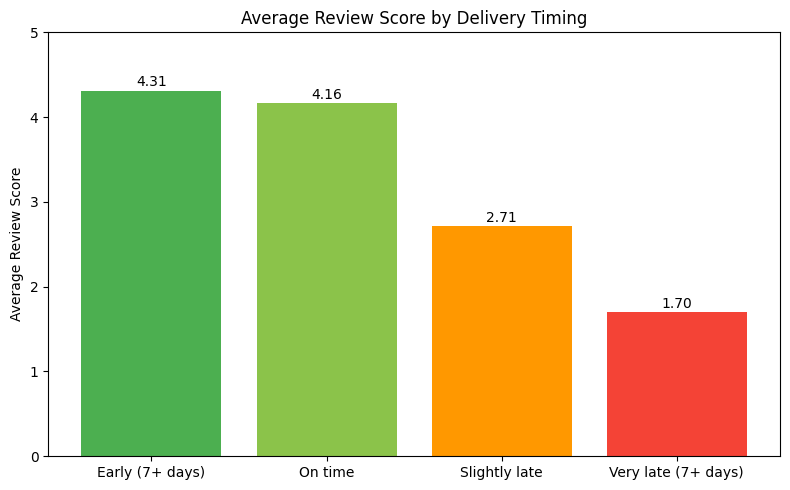

In [20]:
df1 = con.execute("""
    WITH delivery_data AS (
        SELECT 
            o.order_id,
            DATE_DIFF('day', o.order_estimated_delivery_date, o.order_delivered_customer_date) AS days_late,
            r.review_score
        FROM orders o
        JOIN order_reviews r ON o.order_id = r.order_id
        WHERE o.order_status = 'delivered'
          AND o.order_delivered_customer_date IS NOT NULL
    )
    SELECT 
        CASE 
            WHEN days_late <= -7 THEN 'Early (7+ days)'
            WHEN days_late > -7 AND days_late <= 0 THEN 'On time'
            WHEN days_late > 0 AND days_late <= 7 THEN 'Slightly late'
            ELSE 'Very late (7+ days)'
        END AS delivery_bucket,
        AVG(review_score) AS avg_review_score
    FROM delivery_data
    GROUP BY delivery_bucket
""").df()

# enforce logical order
order = ['Early (7+ days)', 'On time', 'Slightly late', 'Very late (7+ days)']
df1['delivery_bucket'] = pd.Categorical(df1['delivery_bucket'], categories=order, ordered=True)
df1 = df1.sort_values('delivery_bucket')

plt.figure(figsize=(8,5))
bars = plt.bar(df1['delivery_bucket'], df1['avg_review_score'], color=['#4CAF50','#8BC34A','#FF9800','#F44336'])
plt.ylabel('Average Review Score')
plt.title('Average Review Score by Delivery Timing')
plt.ylim(0,5)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f'{bar.get_height():.2f}', ha='center')
plt.tight_layout()
plt.savefig('chart1_delivery_vs_review.png', dpi=150)
plt.show()

## Visualize Geographic Delivery Risk

We visualize late-delivery exposure across states to make the highest- and lowest-risk markets easy to compare. This turns the state-level analysis into a prioritization view for potential operational action.


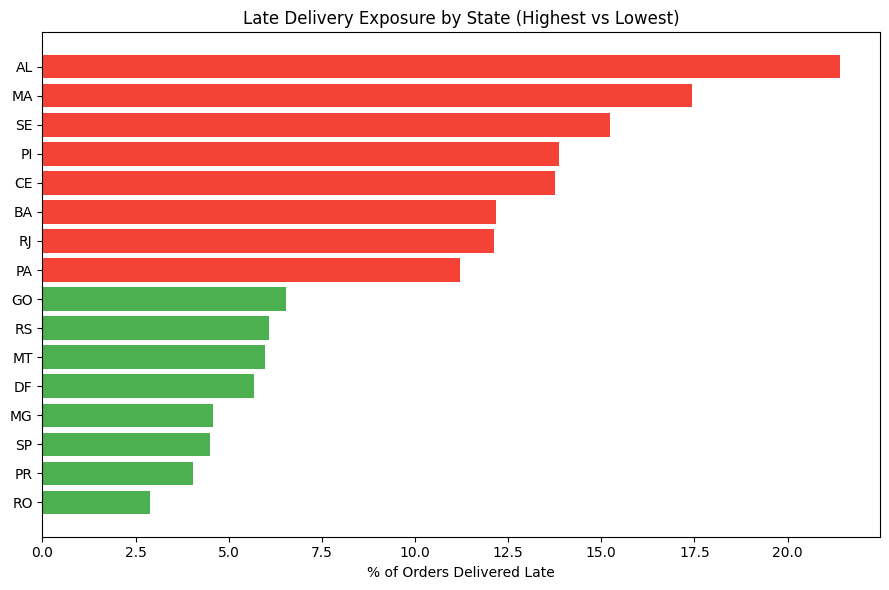

In [21]:
df2 = con.execute("""
    WITH delivery_data AS (
        SELECT 
            c.customer_state,
            DATE_DIFF('day', o.order_estimated_delivery_date, o.order_delivered_customer_date) AS days_late
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
          AND o.order_delivered_customer_date IS NOT NULL
    )
    SELECT 
        customer_state,
        COUNT(*) AS total_orders,
        ROUND(100.0 * SUM(CASE WHEN days_late > 0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_late
    FROM delivery_data
    GROUP BY customer_state
    HAVING COUNT(*) >= 200
    ORDER BY pct_late DESC
""").df()

top_bottom = pd.concat([df2.head(8), df2.tail(8)])

plt.figure(figsize=(9,6))
colors = ['#F44336' if x in df2.head(8)['customer_state'].values else '#4CAF50' for x in top_bottom['customer_state']]
plt.barh(top_bottom['customer_state'], top_bottom['pct_late'], color=colors)
plt.xlabel('% of Orders Delivered Late')
plt.title('Late Delivery Exposure by State (Highest vs Lowest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('chart2_state_exposure.png', dpi=150)
plt.show()

## Visualize Marketplace Revenue Concentration

The cumulative revenue curve shows how quickly marketplace revenue accumulates as sellers are ranked from highest to lowest revenue. This helps assess the degree of seller concentration and the business importance of top-performing sellers.


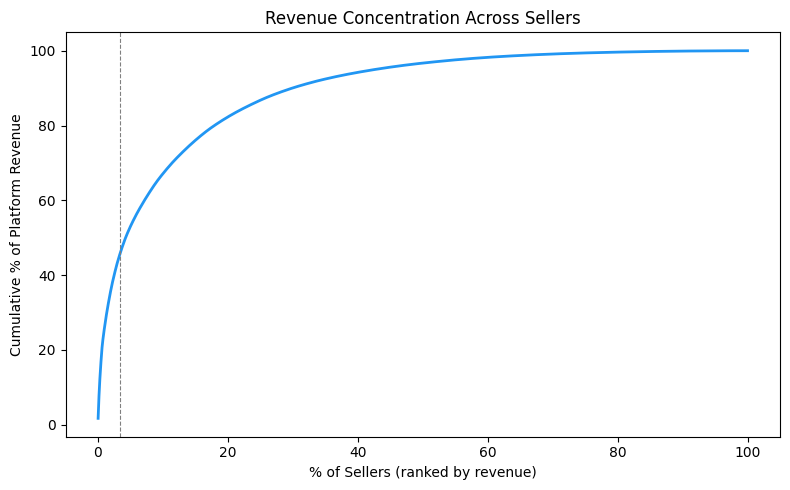

In [22]:
df3 = con.execute("""
    WITH seller_revenue AS (
        SELECT 
            oi.seller_id,
            SUM(oi.price) AS seller_total
        FROM order_items oi
        JOIN orders o ON oi.order_id = o.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY oi.seller_id
    )
    SELECT seller_total FROM seller_revenue ORDER BY seller_total DESC
""").df()

df3['cumulative_pct'] = 100 * df3['seller_total'].cumsum() / df3['seller_total'].sum()
df3['seller_rank_pct'] = 100 * (df3.index + 1) / len(df3)

plt.figure(figsize=(8,5))
plt.plot(df3['seller_rank_pct'], df3['cumulative_pct'], color='#2196F3', linewidth=2)
plt.axvline(x=(100/len(df3))*100, color='gray', linestyle='--', linewidth=0.8)  # marker near top 100 sellers
plt.xlabel('% of Sellers (ranked by revenue)')
plt.ylabel('Cumulative % of Platform Revenue')
plt.title('Revenue Concentration Across Sellers')
plt.tight_layout()
plt.savefig('chart3_seller_concentration.png', dpi=150)
plt.show()

## Prepare the Analysis Outputs

Finally, we export the key analytical datasets used in the project. These outputs can be reused for dashboards, Power BI reporting, or further analysis without repeating the underlying SQL transformations.


In [23]:
import os

export_path = r'C:\Users\Sahil\OneDrive\Desktop\jupyter lab\Project 1\powerbi_exports'
os.makedirs(export_path, exist_ok=True)

# 1. Order-level detail: delivery timing, review score, state, seller, revenue
# This is your main fact table, Power BI will slice and filter off this
con.execute(f"""
    COPY (
        SELECT 
            o.order_id,
            o.order_purchase_timestamp,
            c.customer_state,
            oi.seller_id,
            oi.price,
            oi.freight_value,
            op.payment_installments,
            r.review_score,
            DATE_DIFF('day', o.order_estimated_delivery_date, o.order_delivered_customer_date) AS days_late,
            CASE 
                WHEN DATE_DIFF('day', o.order_estimated_delivery_date, o.order_delivered_customer_date) <= -7 THEN 'Early'
                WHEN DATE_DIFF('day', o.order_estimated_delivery_date, o.order_delivered_customer_date) <= 0 THEN 'On time'
                WHEN DATE_DIFF('day', o.order_estimated_delivery_date, o.order_delivered_customer_date) <= 7 THEN 'Slightly late'
                ELSE 'Very late'
            END AS delivery_bucket
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        JOIN order_items oi ON o.order_id = oi.order_id
        LEFT JOIN order_reviews r ON o.order_id = r.order_id
        LEFT JOIN order_payments op ON o.order_id = op.order_id AND op.payment_type = 'credit_card'
        WHERE o.order_status = 'delivered'
          AND o.order_delivered_customer_date IS NOT NULL
    ) TO '{export_path}\\orders_detail.csv' (HEADER, DELIMITER ',')
""")

# 2. State-level summary: late rate, avg review score, repeat rate
con.execute(f"""
    COPY (
        WITH customer_orders AS (
            SELECT c.customer_unique_id, c.customer_state, COUNT(DISTINCT o.order_id) AS num_orders
            FROM orders o
            JOIN customers c ON o.customer_id = c.customer_id
            WHERE o.order_status = 'delivered'
            GROUP BY c.customer_unique_id, c.customer_state
        ),
        delivery AS (
            SELECT c.customer_state,
                   COUNT(*) AS total_orders,
                   ROUND(100.0 * SUM(CASE WHEN DATE_DIFF('day', o.order_estimated_delivery_date, o.order_delivered_customer_date) > 0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_late,
                   ROUND(AVG(r.review_score), 2) AS avg_review_score
            FROM orders o
            JOIN customers c ON o.customer_id = c.customer_id
            LEFT JOIN order_reviews r ON o.order_id = r.order_id
            WHERE o.order_status = 'delivered' AND o.order_delivered_customer_date IS NOT NULL
            GROUP BY c.customer_state
        ),
        repeat_rate AS (
            SELECT customer_state,
                   ROUND(100.0 * SUM(CASE WHEN num_orders > 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS repeat_rate_pct
            FROM customer_orders
            GROUP BY customer_state
        )
        SELECT d.customer_state, d.total_orders, d.pct_late, d.avg_review_score, rr.repeat_rate_pct
        FROM delivery d
        JOIN repeat_rate rr ON d.customer_state = rr.customer_state
        WHERE d.total_orders >= 100
    ) TO '{export_path}\\state_summary.csv' (HEADER, DELIMITER ',')
""")

# 3. Seller-level summary: revenue, late rate, order count
con.execute(f"""
    COPY (
        SELECT 
            oi.seller_id,
            COUNT(DISTINCT oi.order_id) AS num_orders,
            ROUND(SUM(oi.price), 2) AS total_revenue,
            ROUND(100.0 * SUM(CASE WHEN DATE_DIFF('day', o.order_estimated_delivery_date, o.order_delivered_customer_date) > 0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_late
        FROM order_items oi
        JOIN orders o ON oi.order_id = o.order_id
        WHERE o.order_status = 'delivered' AND o.order_delivered_customer_date IS NOT NULL
        GROUP BY oi.seller_id
        HAVING COUNT(DISTINCT oi.order_id) >= 5
    ) TO '{export_path}\\seller_summary.csv' (HEADER, DELIMITER ',')
""")

print("All three CSVs exported to:", export_path)

All three CSVs exported to: C:\Users\Sahil\OneDrive\Desktop\jupyter lab\Project 1\powerbi_exports
